# Prétraitement et Analyse de Texte : Lewis Carroll

Ce notebook explore le traitement du langage naturel (NLP) en utilisant deux bibliothèques majeures : **NLTK** et **spaCy**. Nous allons nettoyer des textes, les transformer et analyser leur contenu à l'aide de techniques comme le Bag-of-Words (BoW) et TF-IDF.

### 1. Installation et Importation des bibliothèques

Nous installons les ressources nécessaires pour NLTK et le modèle anglais de spaCy.

In [ ]:
import requests # Pour envoyer des requetes HTTP et telecharger les fichiers
import re # Pour le nettoyage des donnees via expressions regulieres
import nltk # Outils de base pour le Traitement du Langage Naturel (NLP)
import spacy # Outils avances pour la lemmatisation et l'analyse syntaxique
import matplotlib.pyplot as plt # Pour la creation de graphiques et visualisations
from wordcloud import WordCloud # Pour generer des nuages de mots

# Telechargement des paquets de donnees necessaires pour NLTK
ressources = ['punkt', 'punkt_tab', 'averaged_perceptron_tagger',
              'averaged_perceptron_tagger_ru', 'maxent_ne_chunker',
              'maxent_ne_chunker_tab', 'words', 'stopwords']
for ressource in ressources:
    nltk.download(ressource, quiet=True)

# Chargement du modele de langue anglaise pre-entraine pour spaCy
try:
    nlp = spacy.load('en_core_web_sm')
except:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load('en_core_web_sm')

print('Bibliotheques pretes !')

Bibliotheques pretes !


### 2. Chargement et Nettoyage des textes

Nous définissons `load_texts()` pour :
1. Récupérer le texte brut via une URL.
2. Nettoyer les caractères spéciaux (non-mots) avec `re.sub`.
3. Isoler le contenu principal en ignorant les licences Gutenberg au début et à la fin.

In [ ]:
def load_texts(urls):
    """Fonction pour telecharger, nettoyer et isoler le texte des livres Gutenberg."""
    corpus = []
    for url in urls:
        # Etape 1 : Recuperation du texte brut
        response = requests.get(url)
        text = response.text

        # Etape 2 : Nettoyage via expressions regulieres (on ne garde que les lettres)
        text_cleaned = re.sub(r'[^a-zA-Z\s]', ' ', text)

        # Etape 3 : Isolation du contenu (entre les balises START et END)
        start_mark = "START OF"
        end_mark = "END OF"
        start_idx = text.find(start_mark)
        end_idx = text.find(end_mark)

        if start_idx != -1 and end_idx != -1:
            final_text = text[start_idx:end_idx]
            final_text = re.sub(r'[^a-zA-Z\s]', ' ', final_text)
            corpus.append(final_text.strip())
        else:
            corpus.append(text_cleaned.strip())

    return corpus

# Liste des URLs des livres a traiter
urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
]

corpus = load_texts(urls)
print(f"Nombre de livres charges : {len(corpus)}")

Nombre de livres charg&#233;s : 3


### 3. Aperçu des textes
Affichons les 200 premiers caractères de chaque livre pour vérifier le nettoyage.

In [ ]:
for i, book_text in enumerate(corpus):
    print(f"--- Livre {i+1} ---")
    print(book_text[:200] + "...")
    print("\n")

--- Livre 1 ---
START OF THE PROJECT GUTENBERG EBOOK ALICE S ADVENTURES IN WONDERLAND    

 Illustration 




Alice s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION    

Conte...


--- Livre 2 ---
START OF THE PROJECT GUTENBERG EBOOK THROUGH THE LOOKING GLASS    

 Illustration 




THROUGH THE LOOKING GLASS

And What Alice Found There

By Lewis Carroll

The Millennium Fulcrum Edit...


--- Livre 3 ---
START OF THE PROJECT GUTENBERG EBOOK A TANGLED TALE    




Produced by Chris Curnow  Carla Foust  Lindy Walsh and the
Online Distributed Proofreading Team at https   www pgdp net 
Music transc...




### 4. Tokenisation

La tokenisation transforme une chaîne de caractères en une liste de mots (tokens). C'est une étape cruciale pour l'analyse statistique.

In [ ]:
from nltk.tokenize import word_tokenize

# Tokenisation de chaque livre dans le corpus
# Nous créons une liste de listes (chaque sous-liste contient les tokens d'un livre)
corpus_tokens = [word_tokenize(text) for text in corpus]

# Affichage des 150 premiers tokens pour chaque livre
for i, tokens in enumerate(corpus_tokens):
    print(f"--- Tokens du Livre {i+1} (150 premiers) ---")
    print(tokens[:150])
    print(f"\nNombre total de tokens dans ce livre : {len(tokens)}\n")

--- Tokens du Livre 1 (150 premiers) ---
['START', 'OF', 'THE', 'PROJECT', 'GUTENBERG', 'EBOOK', 'ALICE', 'S', 'ADVENTURES', 'IN', 'WONDERLAND', 'Illustration', 'Alice', 's', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'THE', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'Contents', 'CHAPTER', 'I', 'Down', 'the', 'Rabbit', 'Hole', 'CHAPTER', 'II', 'The', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', 'A', 'Caucus', 'Race', 'and', 'a', 'Long', 'Tale', 'CHAPTER', 'IV', 'The', 'Rabbit', 'Sends', 'in', 'a', 'Little', 'Bill', 'CHAPTER', 'V', 'Advice', 'from', 'a', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'and', 'Pepper', 'CHAPTER', 'VII', 'A', 'Mad', 'Tea', 'Party', 'CHAPTER', 'VIII', 'The', 'Queen', 's', 'Croquet', 'Ground', 'CHAPTER', 'IX', 'The', 'Mock', 'Turtle', 's', 'Story', 'CHAPTER', 'X', 'The', 'Lobster', 'Quadrille', 'CHAPTER', 'XI', 'Who', 'Stole', 'the', 'Tarts', 'CHAPTER', 'XII', 'Alice', 's', 'Evidence', 'CHAPTER', 'I', 'Down', 'the', 'Rabbit', 'Hole', 'Alice', 'was', 'beginning

### 5. Suppression des mots vides (Stop Words)

Les mots vides sont des mots très fréquents qui n'apportent que peu de valeur sémantique. Nous utilisons la liste standard de NLTK pour les filtrer.

In [ ]:
from nltk.corpus import stopwords

# Liste des mots vides en anglais
stop_words = set(stopwords.words('english'))

# Filtrage du corpus
corpus_filtered = []
for tokens in corpus_tokens:
    # On ne garde que les mots qui ne sont pas dans la liste des stop_words
    # et on met tout en minuscule pour la comparaison
    filtered = [w for w in tokens if w.lower() not in stop_words]
    corpus_filtered.append(filtered)

# Vérification : comptons quelques mots vides cibles
target_stops = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']

print("Vérification de la suppression :")
for i, filtered_tokens in enumerate(corpus_filtered):
    found = [w for w in filtered_tokens if w.lower() in target_stops]
    print(f"Livre {i+1} : {len(found)} mots vides restants parmi la liste cible.")

print(f"\nExemple de tokens après filtrage (Livre 1) : {corpus_filtered[0][:20]}")

Vérification de la suppression :
Livre 1 : 0 mots vides restants parmi la liste cible.
Livre 2 : 0 mots vides restants parmi la liste cible.
Livre 3 : 0 mots vides restants parmi la liste cible.

Exemple de tokens après filtrage (Livre 1) : ['START', 'PROJECT', 'GUTENBERG', 'EBOOK', 'ALICE', 'ADVENTURES', 'WONDERLAND', 'Illustration', 'Alice', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'Contents', 'CHAPTER', 'Rabbit', 'Hole']


### 6. Racinisation (Stemming) avec NLTK

Le stemming réduit un mot à sa racine en supprimant les suffixes. Nous utilisons ici le `PorterStemmer`.

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# Application du stemming sur les 50 premiers jetons filtrés du premier livre
stemmed_tokens = [stemmer.stem(w) for w in corpus_filtered[0]]

print("50 premiers jetons après Stemming (Livre 1) :")
print(stemmed_tokens[:50])

50 premiers jetons après Stemming (Livre 1) :
['start', 'project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter']


### 7. Lemmatisation avec spaCy

La lemmatisation est plus fine car elle transforme le mot en sa forme de base (ex: 'running' devient 'run') en tenant compte du contexte grammatical.

In [ ]:
# Pour spaCy, nous traitons le texte brut nettoyé pour bénéficier de l'analyse contextuelle
# Nous prenons une portion du premier livre pour l'exemple
doc = nlp(corpus[0][:2000])

lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_space]

print("50 premiers jetons après Lemmatisation (Livre 1) :")
print(lemmatized_tokens[:50])

50 premiers jetons après Lemmatisation (Livre 1) :
['start', 'project', 'GUTENBERG', 'EBOOK', 'ALICE', 'S', 'ADVENTURES', 'WONDERLAND', 'Illustration', 'Alice', 's', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'content', 'CHAPTER', 'Rabbit', 'Hole', 'CHAPTER', 'II', 'Pool', 'Tears', 'CHAPTER', 'III', 'Caucus', 'Race', 'Long', 'Tale', 'CHAPTER', 'IV', 'Rabbit', 'send', 'little', 'Bill', 'CHAPTER', 'V', 'Advice', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'Pepper', 'CHAPTER', 'VII', 'Mad', 'Tea']


### 8. Analyse : Stemming vs Lemmatisation

**Quelle est la différence ?**
- Le **Stemming** (racinisation) est un processus heuristique qui coupe la fin des mots. C'est rapide mais cela peut créer des mots qui n'existent pas (ex: 'univer' pour 'university').
- La **Lemmatisation** est un processus linguistique qui utilise un dictionnaire et une analyse morphologique pour ramener le mot à son lemme (le mot tel qu'il apparaît dans le dictionnaire).

**Pourquoi cette différence ?**
Le stemming est purement algorithmique (règles de coupe), alors que la lemmatisation comprend la structure de la langue. On préfère la lemmatisation pour des analyses précises, et le stemming pour des tâches où la vitesse prime sur la précision linguistique.

### 9. Étiquetage POS (Part-of-Speech Tagging)

L'étiquetage morphosyntaxique permet d'identifier la fonction grammaticale de chaque mot (nom, verbe, adjectif, etc.).

In [ ]:
from nltk import pos_tag

# Exemple sur les 20 premiers tokens du Livre 1
pos_tags = pos_tag(corpus_tokens[0][:20])
print("Étiquettes POS (Livre 1) :")
print(pos_tags)

Étiquettes POS (Livre 1) :
[('START', 'NNP'), ('OF', 'IN'), ('THE', 'NNP'), ('PROJECT', 'NNP'), ('GUTENBERG', 'NNP'), ('EBOOK', 'NNP'), ('ALICE', 'NNP'), ('S', 'NNP'), ('ADVENTURES', 'NNP'), ('IN', 'NNP'), ('WONDERLAND', 'NNP'), ('Illustration', 'NNP'), ('Alice', 'NNP'), ('s', 'NN'), ('Adventures', 'NNP'), ('in', 'IN'), ('Wonderland', 'NNP'), ('by', 'IN'), ('Lewis', 'NNP'), ('Carroll', 'NNP')]


### 10. Reconnaissance d'Entités Nommées (NER)

Le NER permet de détecter automatiquement des entités comme des noms de personnes, des lieux ou des organisations.

In [ ]:
from nltk import ne_chunk, pos_tag

# Identification des entites sur un echantillon de 100 tokens
ner_tree = ne_chunk(pos_tag(corpus_tokens[0][:100]))
print('Arbre NER (extrait) :')
print(ner_tree[:10])

Arbre NER (extrait) :
[('START', 'NNP'), ('OF', 'IN'), Tree('ORGANIZATION', [('THE', 'NNP')]), Tree('ORGANIZATION', [('PROJECT', 'NNP')]), ('GUTENBERG', 'NNP'), ('EBOOK', 'NNP'), ('ALICE', 'NNP'), ('S', 'NNP'), ('ADVENTURES', 'NNP'), ('IN', 'NNP')]


## Analyse du texte

### 1. Nuages de mots (WordClouds)
Visualisons les thèmes dominants pour chaque livre.

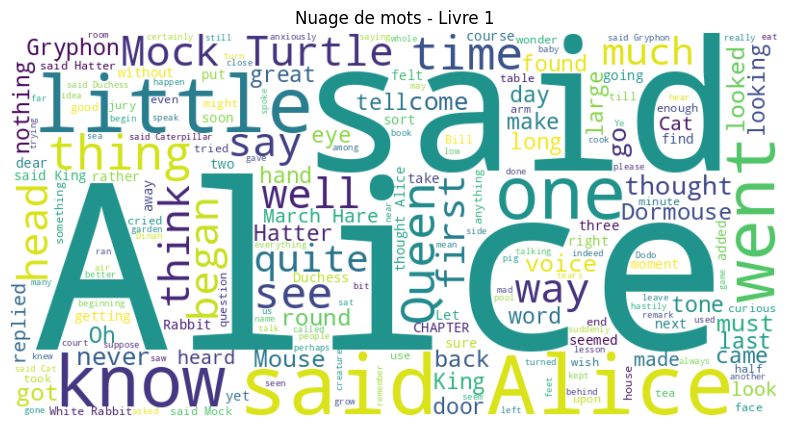

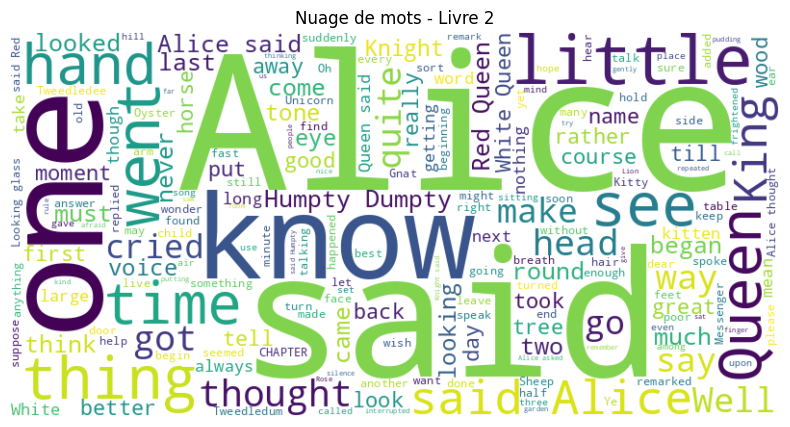

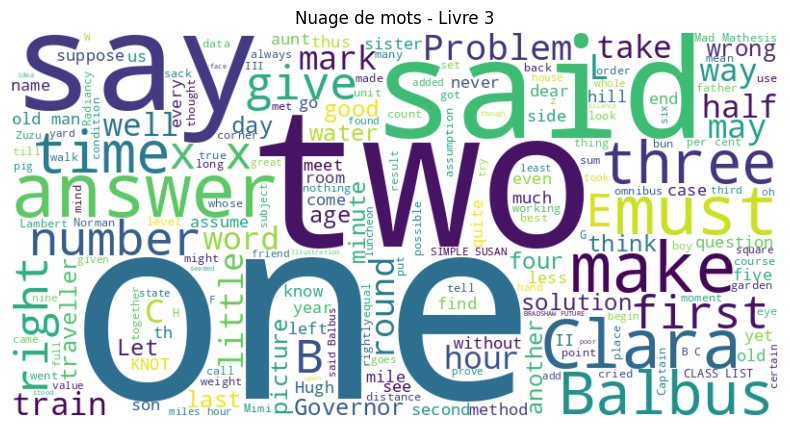

In [ ]:
def plot_wordcloud(text_list, title):
    text = " ".join(text_list)
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

for i in range(len(corpus_filtered)):
    plot_wordcloud(corpus_filtered[i], f"Nuage de mots - Livre {i+1}")

### 2. Bag-of-Words (BoW) et TF-IDF

Nous comparons ici la fréquence brute (BoW) avec le score TF-IDF qui met en avant les mots uniques à chaque document.

Top 5 mots par Fréquence (BoW) :


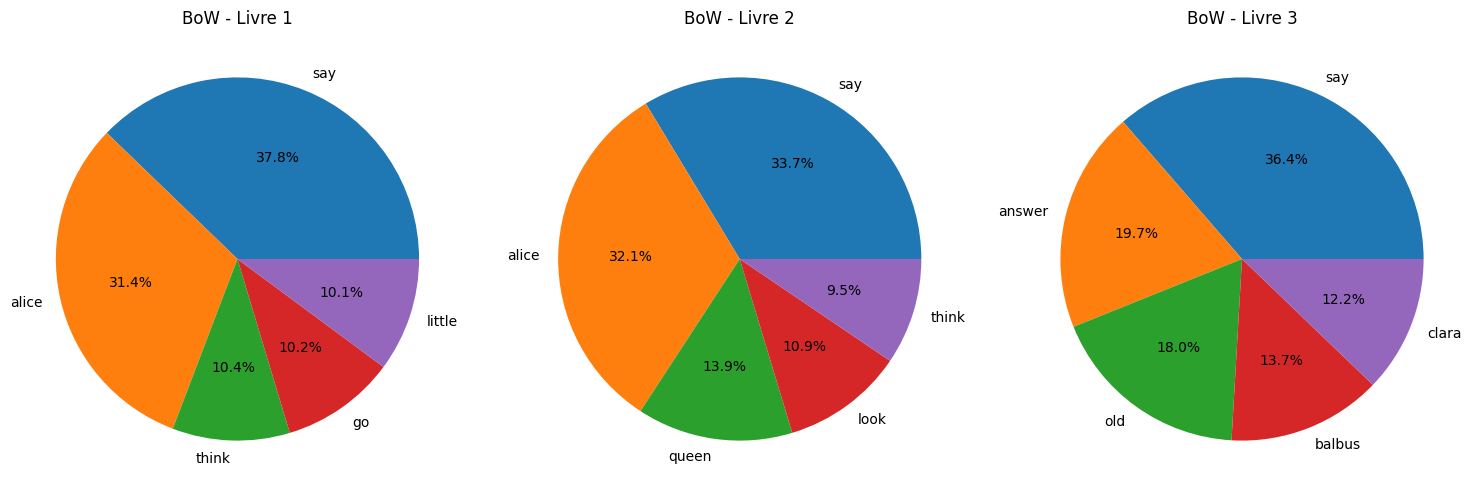

Top 5 mots par Pertinence (TF-IDF) :


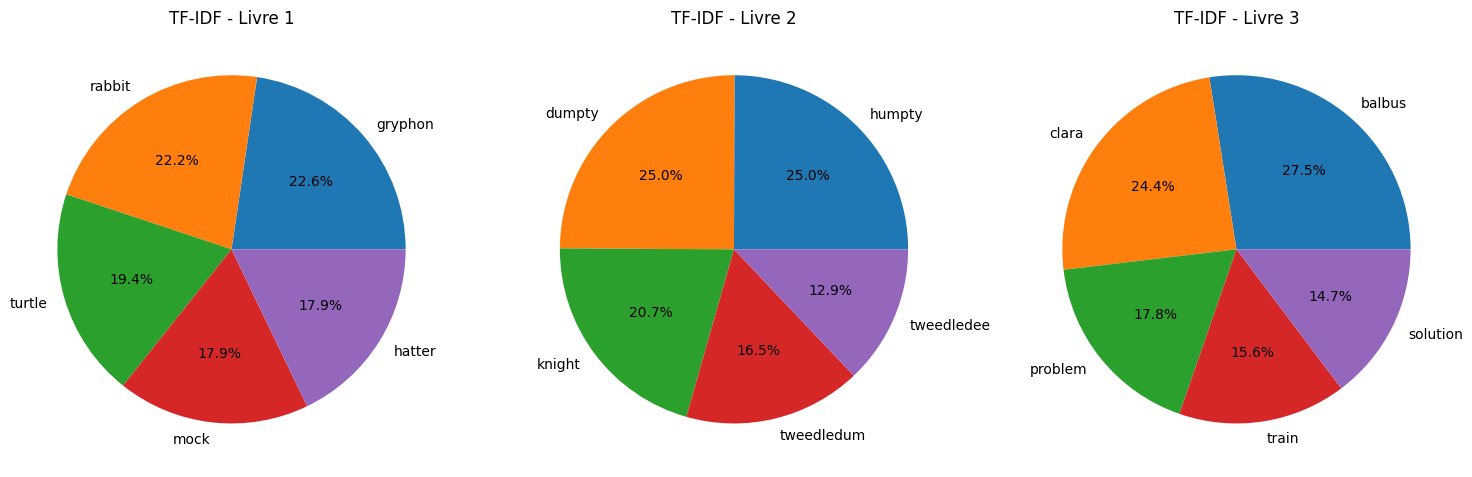

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

# Préparation des textes lemmatisés pour l'analyse
corpus_lemmed_str = []
for text in corpus:
    doc = nlp(text.lower())
    lemmas = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    corpus_lemmed_str.append(" ".join(lemmas))

# 1. Bag-of-Words
bow_vec = CountVectorizer()
bow_matrix = bow_vec.fit_transform(corpus_lemmed_str)
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vec.get_feature_names_out())

# 2. TF-IDF (min_df=1, max_df=2 pour petit corpus)
tfidf_vec = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = tfidf_vec.fit_transform(corpus_lemmed_str)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vec.get_feature_names_out())

def plot_top_5(df, title):
    plt.figure(figsize=(15, 5))
    for i in range(len(df)):
        plt.subplot(1, 3, i+1)
        top5 = df.iloc[i].sort_values(ascending=False).head(5)
        plt.pie(top5, labels=top5.index, autopct='%1.1f%%')
        plt.title(f"{title} - Livre {i+1}")
    plt.tight_layout()
    plt.show()

print("Top 5 mots par Fréquence (BoW) :")
plot_top_5(bow_df, "BoW")

print("Top 5 mots par Pertinence (TF-IDF) :")
plot_top_5(tfidf_df, "TF-IDF")

### 3. Diagrammes circulaires des 5 mots les plus fréquents

Identifions les 5 mots dominants par livre.

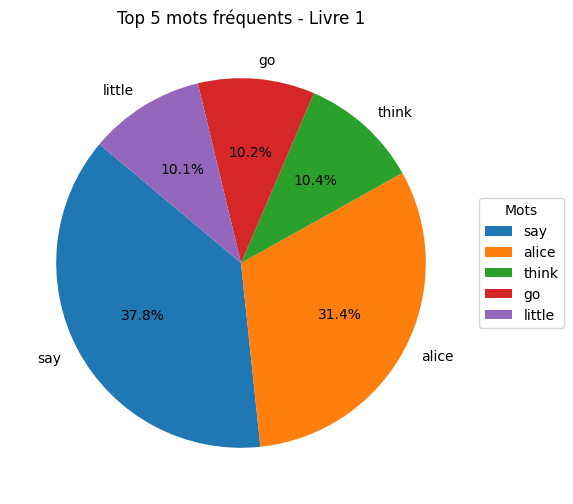

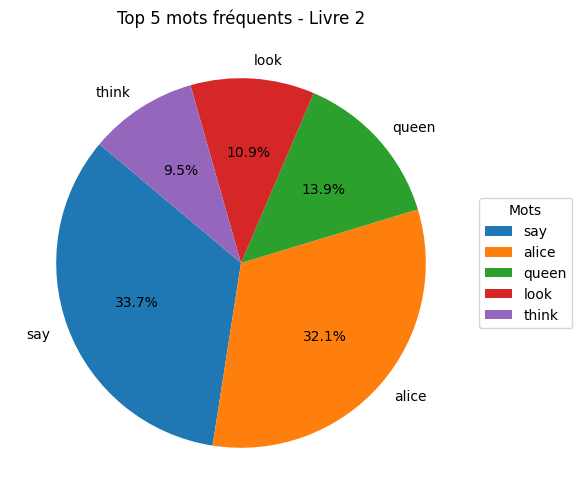

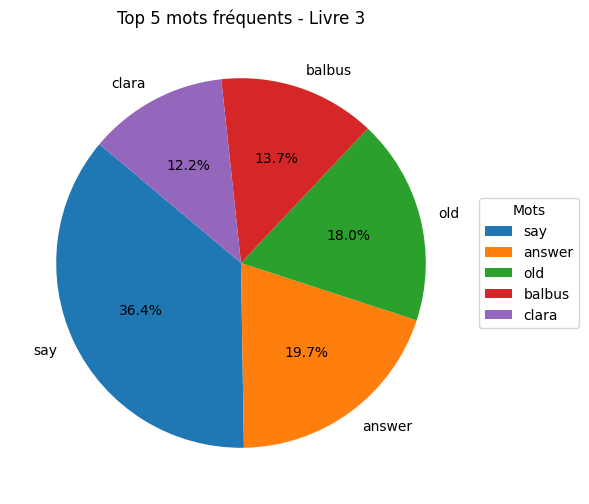

In [ ]:
def plot_top_words(df, doc_index, title):
    # Extraction des fréquences pour le document donné
    top_5 = df.iloc[doc_index].sort_values(ascending=False).head(5)

    plt.figure(figsize=(8, 6))
    plt.pie(top_5, labels=top_5.index, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.legend(top_5.index, title="Mots", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.show()

for i in range(len(corpus)):
    plot_top_words(bow_df, i, f"Top 5 mots fréquents - Livre {i+1}")

### 4. Analyse de TF-IDF

Le BoW montre souvent des mots communs comme 'say' ou 'alice'. Le **TF-IDF** va pénaliser les mots trop fréquents dans tout le corpus pour faire ressortir les mots spécifiques à chaque livre.

Nouveaux diagrammes basés sur le score TF-IDF :


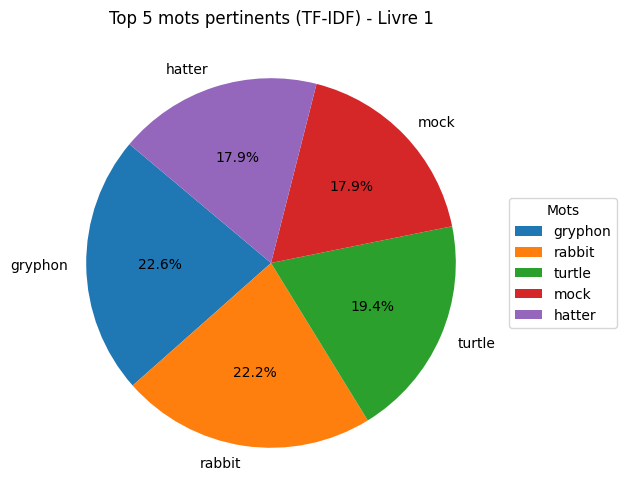

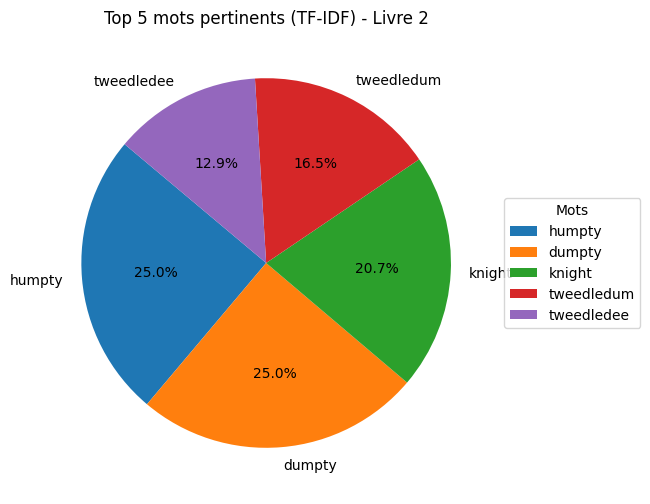

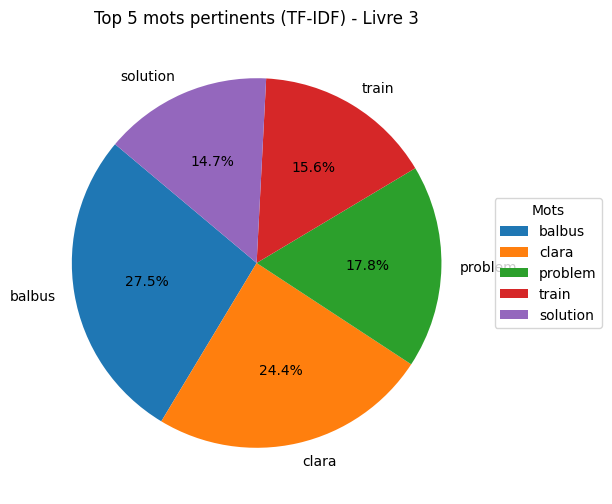

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Création du vectoriseur TF-IDF
# min_df=1 (mot doit être dans au moins 1 doc), max_df=2 (mot ne doit pas être dans tous les docs)
tfidf_vec = TfidfVectorizer(min_df=1, max_df=2)
X_tfidf = tfidf_vec.fit_transform(corpus_lemmed_str)

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out())

print("Nouveaux diagrammes basés sur le score TF-IDF :")
for i in range(len(corpus)):
    plot_top_words(tfidf_df, i, f"Top 5 mots pertinents (TF-IDF) - Livre {i+1}")